# Практична робота 3.3
## Аналіз набору даних з Kaggle

**Мета роботи:** навчитися завантажувати, обробляти, очищати та аналізувати
реальні набори даних з платформи Kaggle.

### 1. Пошук набору даних на Kaggle

На сайті [Kaggle](https://www.kaggle.com/) обрано набір даних із категорії
суспільної аналітики — пости соціальної мережі Reddit, присвячені війні в Україні.

Набір підходить для цієї роботи, бо містить одночасно:

- **числові змінні** — кількість апвотів, кількість коментарів, частка позитивних
  голосів, час публікації;
- **категоріальні змінні** — спільнота (`subreddit`), автор поста;
- **текстові змінні** — заголовок і текст поста.

### 2. Завантаження даних

Набір завантажено з Kaggle у форматі CSV. Основний файл — `original_data.csv`
(10 000 записів, 12 стовпців).

Щоб не зберігати в репозиторії три копії одного й того самого файлу,
ноутбук читає дані з папки практичної 3.5, де вони вже лежать.

### 3. Завантаження та перегляд даних у Python

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження даних
df = pd.read_csv('../Practica3_5/archive/original_data.csv')

# Перегляд перших рядків
print(df.head())

   Unnamed: 0           subreddit  \
0           0  NonCredibleDefense   
1           1             ukraine   
2           2   UkrainianConflict   
3           3              europe   
4           4              europe   

                                            selftext author_fullname  \
0                                                NaN     t2_4dfoopu9   
1                                                NaN     t2_3so708z2   
2                                                NaN     t2_p5qo3hyf   
3  \r\nThis megathread is meant for discussion of...        t2_ojkhp   
4  This megathread is meant for discussion of the...        t2_ojkhp   

                                               title  upvote_ratio    ups  \
0  Damn...we blinked and missed the T-34 stage of...          0.79  10398   
1  Finnish🇫🇮 volunteer sends greetings home from ...          0.90   2100   
2  Massive #HIMARS strikes 60km from the front in...          0.79    834   
3                     War in Ukraine

In [2]:
# Огляд інформації про набір даних
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       10000 non-null  int64  
 1   subreddit        10000 non-null  str    
 2   selftext         4137 non-null   str    
 3   author_fullname  10000 non-null  str    
 4   title            10000 non-null  str    
 5   upvote_ratio     10000 non-null  float64
 6   ups              10000 non-null  int64  
 7   created          10000 non-null  int64  
 8   created_utc      10000 non-null  int64  
 9   num_comments     10000 non-null  int64  
 10  author           10000 non-null  str    
 11  id               10000 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 937.6 KB
None


In [3]:
print('Рядків:  ', df.shape[0])
print('Стовпців:', df.shape[1])
print()
print('Назви стовпців:')
print(list(df.columns))

Рядків:   10000
Стовпців: 12

Назви стовпців:
['Unnamed: 0', 'subreddit', 'selftext', 'author_fullname', 'title', 'upvote_ratio', 'ups', 'created', 'created_utc', 'num_comments', 'author', 'id']


### 4. Очищення даних

In [4]:
# Перевірка на пропущені значення
print(df.isnull().sum())

Unnamed: 0            0
subreddit             0
selftext           5863
author_fullname       0
title                 0
upvote_ratio          0
ups                   0
created               0
created_utc           0
num_comments          0
author                0
id                    0
dtype: int64


In [5]:
# Частка пропусків у відсотках
print((df.isnull().mean() * 100).round(1))

Unnamed: 0          0.0
subreddit           0.0
selftext           58.6
author_fullname     0.0
title               0.0
upvote_ratio        0.0
ups                 0.0
created             0.0
created_utc         0.0
num_comments        0.0
author              0.0
id                  0.0
dtype: float64


In [6]:
# Стовпець 'Unnamed: 0' - це службовий номер рядка з файлу, він не потрібен
df = df.drop(columns=['Unnamed: 0'])

# Пропуски є лише в текстових стовпцях, тому середнім їх заповнити не можна.
# selftext порожній там, де пост є посиланням або картинкою.
df['selftext'] = df['selftext'].fillna('немає тексту')
df['author'] = df['author'].fillna('невідомий')
df['author_fullname'] = df['author_fullname'].fillna('невідомий')

print('Пропущених значень залишилось:', df.isnull().sum().sum())

Пропущених значень залишилось: 0


In [7]:
# Видалення дублікатів
print('Рядків до видалення дублікатів: ', len(df))
print('Унікальних постів за id:        ', df['id'].nunique())

df = df.drop_duplicates(subset='id').reset_index(drop=True)
print('Рядків після видалення:         ', len(df))

Рядків до видалення дублікатів:  10000
Унікальних постів за id:         241
Рядків після видалення:          241


In [8]:
# Перетворення категоріальної змінної на числову
df['subreddit_code'] = df['subreddit'].astype('category').cat.codes

print(df[['subreddit', 'subreddit_code']].head(10))

            subreddit  subreddit_code
0  NonCredibleDefense               7
1             ukraine              41
2   UkrainianConflict              18
3              europe              28
4              europe              28
5              europe              28
6     Cursedgunimages               3
7              europe              28
8              europe              28
9              europe              28


### 5. Описова статистика

In [9]:
# Описова статистика для числових змінних
numeric = df[['ups', 'num_comments', 'upvote_ratio']]
print(numeric.describe())

                ups  num_comments  upvote_ratio
count    241.000000    241.000000    241.000000
mean      79.721992    259.804979      0.760456
std      686.835862   1340.171080      0.155891
min        0.000000      0.000000      0.300000
25%        1.000000      0.000000      0.620000
50%        4.000000      0.000000      0.790000
75%        9.000000     35.000000      0.900000
max    10398.000000   9524.000000      0.900000


In [10]:
# Основні показники окремо
print('Середнє значення:')
print(numeric.mean().round(2))
print()
print('Медіана:')
print(numeric.median().round(2))
print()
print('Стандартне відхилення:')
print(numeric.std().round(2))

Середнє значення:
ups              79.72
num_comments    259.80
upvote_ratio      0.76
dtype: float64

Медіана:
ups             4.00
num_comments    0.00
upvote_ratio    0.79
dtype: float64

Стандартне відхилення:
ups              686.84
num_comments    1340.17
upvote_ratio       0.16
dtype: float64


In [11]:
# Скільки постів у кожній спільноті
print(df['subreddit'].value_counts().head(10))

subreddit
caps                 71
insurgencetv         65
UkrainWarMonitor     17
PolitikWirtschaft    12
europe               10
UkrainianConflict     6
u_liberty_ukraine     6
u_Newsat11co          5
zvorsky_youtube       4
essentialpost         3
Name: count, dtype: int64


### 6. Візуалізація даних

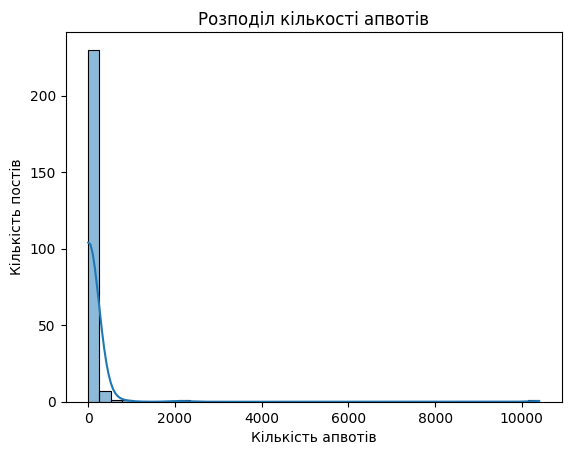

In [12]:
# Гістограма: розподіл кількості апвотів
sns.histplot(df['ups'], bins=40, kde=True)
plt.title('Розподіл кількості апвотів')
plt.xlabel('Кількість апвотів')
plt.ylabel('Кількість постів')
plt.show()

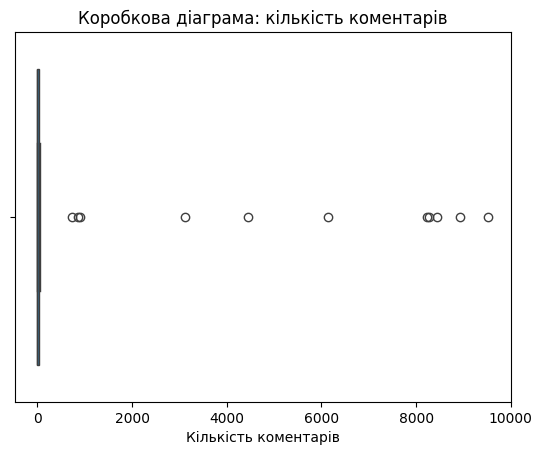

In [13]:
# Коробкова діаграма: аналіз викидів за кількістю коментарів
sns.boxplot(x=df['num_comments'])
plt.title('Коробкова діаграма: кількість коментарів')
plt.xlabel('Кількість коментарів')
plt.show()

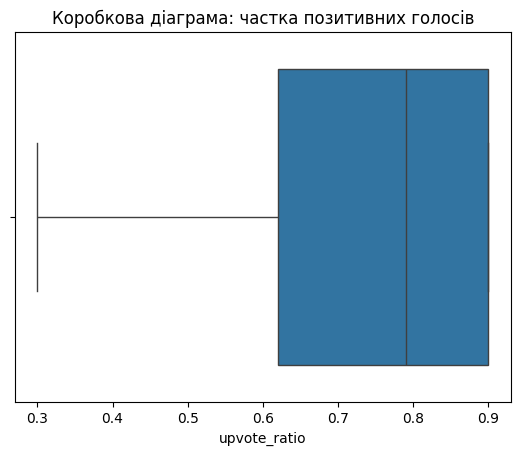

In [14]:
# Коробкова діаграма для частки позитивних голосів
sns.boxplot(x=df['upvote_ratio'])
plt.title('Коробкова діаграма: частка позитивних голосів')
plt.xlabel('upvote_ratio')
plt.show()

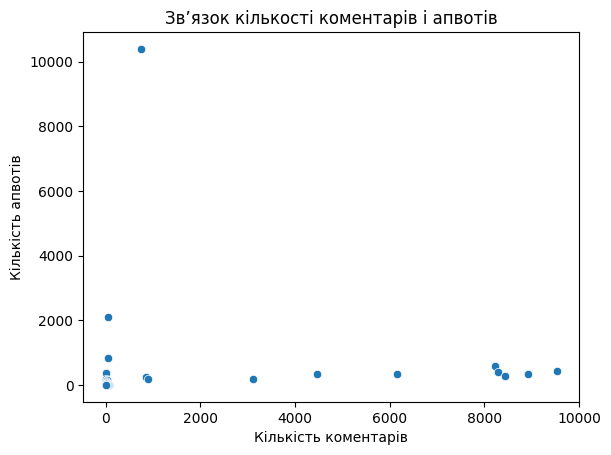

In [15]:
# Діаграма розсіювання: коментарі та апвоти
sns.scatterplot(x=df['num_comments'], y=df['ups'])
plt.title('Звʼязок кількості коментарів і апвотів')
plt.xlabel('Кількість коментарів')
plt.ylabel('Кількість апвотів')
plt.show()

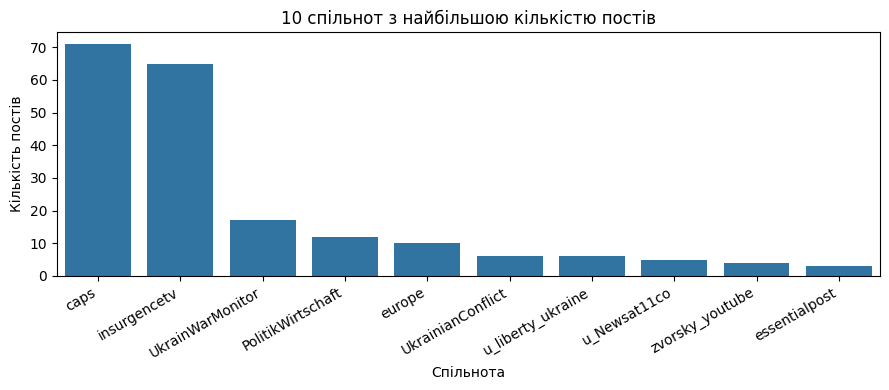

In [16]:
# Стовпчикова діаграма: 10 найактивніших спільнот
top10 = df['subreddit'].value_counts().head(10)

plt.figure(figsize=(9, 4))
sns.barplot(x=top10.index, y=top10.values)
plt.title('10 спільнот з найбільшою кількістю постів')
plt.xlabel('Спільнота')
plt.ylabel('Кількість постів')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 7. Кореляційний аналіз

In [17]:
# Кореляційна матриця для кількісних змінних
correlation_matrix = df[['ups', 'num_comments', 'upvote_ratio', 'subreddit_code']].corr()

print(correlation_matrix.round(3))

                  ups  num_comments  upvote_ratio  subreddit_code
ups             1.000         0.113         0.020          -0.111
num_comments    0.113         1.000        -0.014           0.043
upvote_ratio    0.020        -0.014         1.000           0.181
subreddit_code -0.111         0.043         0.181           1.000


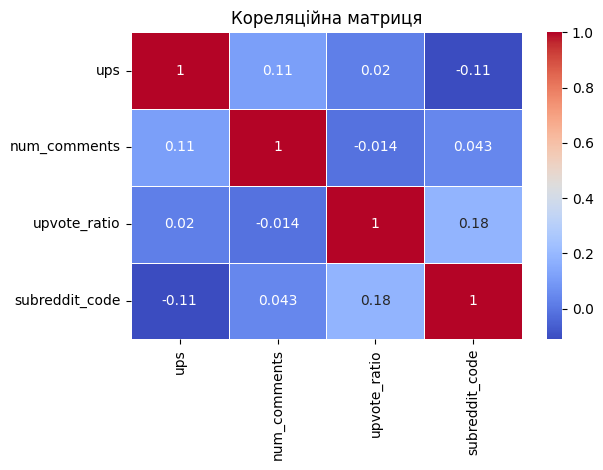

In [18]:
# Візуалізація кореляційної матриці
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Кореляційна матриця')
plt.tight_layout()
plt.show()

### 8. Звітування. Висновки

**Опис набору даних.** Використано набір даних з Kaggle — 10 000 записів
про пости Reddit на тему війни в Україні. Кожен запис містить спільноту,
автора, заголовок і текст поста, час публікації, кількість апвотів,
кількість коментарів та частку позитивних голосів.

**Очищення даних.** Видалено службовий стовпець `Unnamed: 0`.
Пропуски виявились лише в одному стовпці — `selftext` (58.6 % записів),
бо велика частина постів є просто посиланнями або картинками.
Заповнити такий пропуск середнім значенням не можна — стовпець текстовий,
тому використано замітку «немає тексту».

Найважливіше в очищенні — дублікати. Виявилось, що 10 000 рядків описують лише
**241 унікальний пост**: кожен пост повторюється стільки разів, скільки в наборі
зібрано його коментарів. Без дедублікації вся статистика була б зміщена
в бік постів із великою кількістю коментарів — саме вони дали б найбільше
повторів. Після очищення в роботі залишився 241 запис.

Категоріальну змінну `subreddit` перетворено на числовий код через `cat.codes`.

**Описова статистика.**

| Змінна | Середнє | Медіана | Ст. відхилення | Максимум |
|---|---|---|---|---|
| Апвоти (`ups`) | 79.7 | 4.0 | 686.8 | 10 398 |
| Коментарі (`num_comments`) | 259.8 | 0.0 | 1340.2 | 9 524 |
| Частка позитивних (`upvote_ratio`) | 0.76 | 0.79 | 0.16 | 0.90 |

Головне спостереження: **середнє значно більше за медіану**.
Типовий пост набирає 4 апвоти, а середнє — майже 80, тобто у 20 разів більше.
Для коментарів розрив ще різкіший: медіана нульова, а середнє — 260.
Стандартне відхилення в обох випадках у кілька разів перевищує середнє.
Усе це ознаки розподілу з довгим «хвостом»: більшість постів залишаються
непоміченими, а поодинокі стають вірусними й перетягують середнє на себе.
Для таких даних медіана описує типовий пост набагато чесніше, ніж середнє.

Виняток — `upvote_ratio`: тут середнє й медіана майже збігаються (0.76 і 0.79),
розподіл рівномірний, бо це частка, обмежена зверху одиницею.

**Візуалізація.** Гістограма підтверджує асиметрію: майже всі пости зосереджені
біля нуля, і лише поодинокі набирають тисячі апвотів. Коробкові діаграми
за апвотами й коментарями складаються переважно з викидів — точок за межами
«вусів»; натомість `upvote_ratio` має нормальний вигляд, більшість значень
лежить між 0.62 і 0.90. Стовпчикова діаграма показує, що дані зібрані
з кількох десятків спільнот, але 136 постів із 241 (56 %) припадають
лише на дві — `caps` та `insurgencetv`.

**Кореляційний аналіз.** Усі зв'язки між числовими змінними слабкі:

- `ups` — `num_comments`: **0.11** — найсильніший зв'язок у наборі.
  Обговорюваність і популярність зростають разом, але далеко не завжди.
- `ups` — `upvote_ratio`: **0.02** — зв'язку практично немає. Те, що пост
  схвалюють ті, хто його побачив, ще не означає, що він набере багато голосів.
- `num_comments` — `upvote_ratio`: **-0.01** — незалежні величини.
- Кореляції зі стовпцем `subreddit_code` інтерпретувати не можна:
  це порядковий номер спільноти за алфавітом, а не величина.

Причина слабких коефіцієнтів видно на діаграмі розсіювання: точки утворюють
не лінію, а щільну хмару біля нуля з кількома далекими викидами.
Лінійний коефіцієнт кореляції на таких даних занижує реальний зв'язок.

**Загальний висновок.** Набір даних придатний для аналізу, але потребує
обережності на двох етапах. По-перше, 90 % рядків у ньому — повтори,
і без дедублікації будь-яка статистика буде хибною. По-друге, розподіли
числових змінних різко асиметричні, тому середнє значення тут уводить
в оману — типовий пост описує медіана. Для подальшої роботи з такими даними
варто логарифмувати змінні з великим розкидом.

**Результати завантажено на GitHub** — репозиторій `Praktik2026`,
папка `Thema 3/Practica3_3`.